In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc3 as pm
import theano
import xarray as xr
from statistics import NormalDist

print(f"Running on PyMC3 v{pm.__version__}")

Running on PyMC3 v3.11.2


In [2]:
%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")


In [3]:
data = pd.read_csv("data_rdm_dem.csv").dropna()
participantcode = data.participant.unique()

data["confidence"] = data["confidence"].astype(theano.config.floatX)

In [4]:
participant_idx, participant = pd.factorize(data.participant)
coords = {
    "participant": participant,
    "obs_id": np.arange(len(participant_idx)),
}
m_conf=data["confidence"].mean()
sd_conf=data["confidence"].std()

median_conf=data["confidence"].median()

In [5]:
with pm.Model(coords=coords) as confi:
    participant_idx = pm.Data("participant_idx", participant_idx, dims="obs_id")
    # Hyperpriors for group nodes
    mu_a = pm.Normal("mu_a", mu=m_conf, sigma=0.5)
    sigma_a = pm.HalfNormal("sigma_a", sd_conf)
    mu_b = pm.Normal("mu_b", mu=0.0, sigma=0.5)
    sigma_b = pm.HalfNormal("sigma_b",0.5)
    mu_b_pdi = pm.Normal("mu_b_pdi", mu=0.0, sigma=0.5)
    sigma_b_pdi = pm.HalfNormal("sigma_b_pdi", 0.5)
    

    # Intercept for each county, distributed around group mean mu_a
    # Above we just set mu and sd to a fixed value while here we
    # plug in a common group distribution for all a and b (which are
    # vectors of length n_counties).
    a = pm.Normal("a", mu=mu_a, sigma=sigma_a, dims="participant")
    # effect difference between basement and floor level
    b = pm.Normal("b", mu=mu_b, sigma=sigma_b, dims="participant")
    b_pdi = pm.Normal("b_pdi", mu=mu_b_pdi, sigma=sigma_b_pdi, dims="participant")

    # Model error
    eps = pm.HalfCauchy("eps", 5.0)

    confidence_est = a[participant_idx] + b[participant_idx] * data.session.values+ b_pdi[participant_idx] * data.pdi.values


    # Data likelihood
    confidence_like = pm.Normal("confidence_like ", mu=confidence_est, sigma=eps, observed=data.confidence, dims="obs_id")
    
    

In [6]:
with hierarchical_model:
    hierarchical_trace = pm.sample(5000, tune=5000, target_accept=0.99, return_inferencedata=True)

NameError: name 'hierarchical_model' is not defined

In [9]:
pm.model_to_graphviz(pm.model_to_graphviz(hierarchical_model))

AttributeError: 'Digraph' object has no attribute 'named_vars'

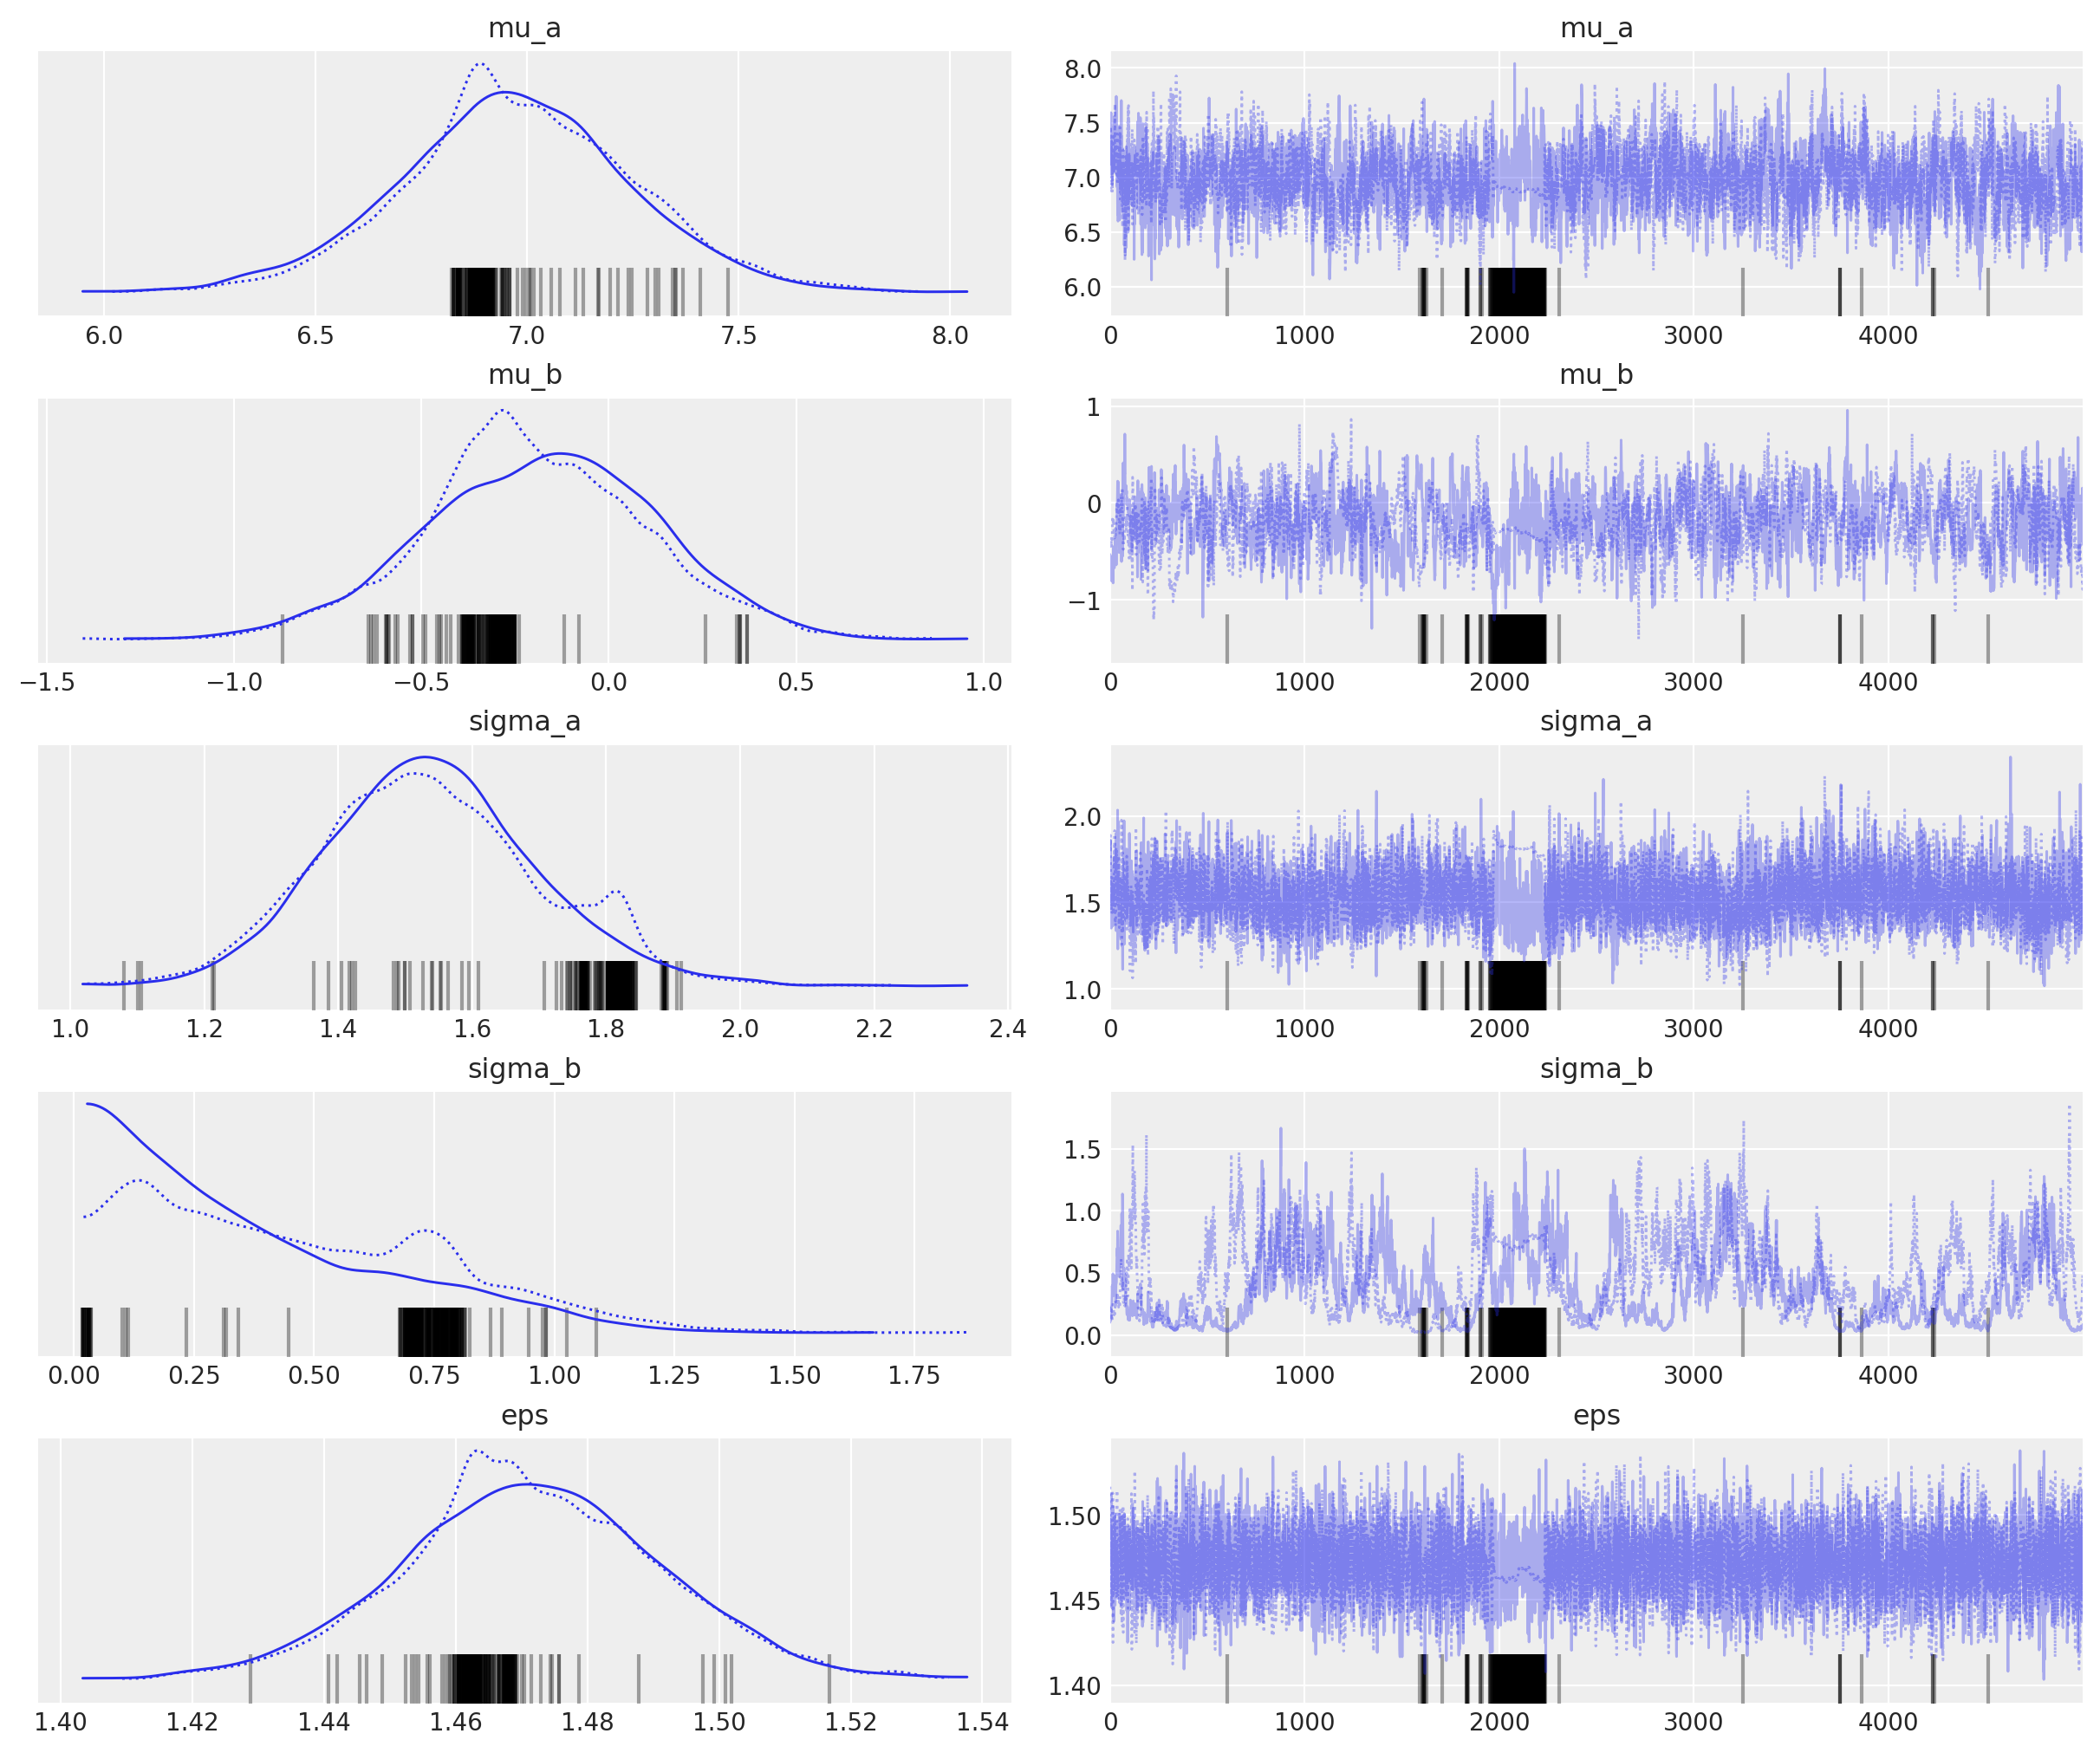

In [10]:
az.plot_trace(hierarchical_trace, var_names=["mu_a", "mu_b", "sigma_a", "sigma_b", "eps"]);


In [11]:
stat_tms_reg_conf=pm.summary(hierarchical_trace)
stat_tms_reg_conf


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_a,6.975,0.273,6.466,7.512,0.009,0.007,831.0,1738.0,1.00
mu_b,-0.190,0.299,-0.789,0.354,0.013,0.009,513.0,964.0,1.00
mu_b_pdi,0.003,0.003,-0.003,0.009,0.000,0.000,356.0,529.0,1.01
a[AD20],6.324,0.641,5.111,7.532,0.020,0.014,1011.0,2579.0,1.00
a[AF12],5.443,0.740,4.111,6.870,0.044,0.032,299.0,1378.0,1.01
...,...,...,...,...,...,...,...,...,...
b_pdi[ZZ99],0.002,0.005,-0.007,0.012,0.000,0.000,702.0,1144.0,1.00
sigma_a,1.539,0.162,1.251,1.850,0.009,0.007,323.0,607.0,1.01
sigma_b,0.418,0.302,0.018,0.952,0.039,0.028,55.0,157.0,1.03
sigma_b_pdi,0.003,0.002,0.000,0.007,0.000,0.000,53.0,48.0,1.03


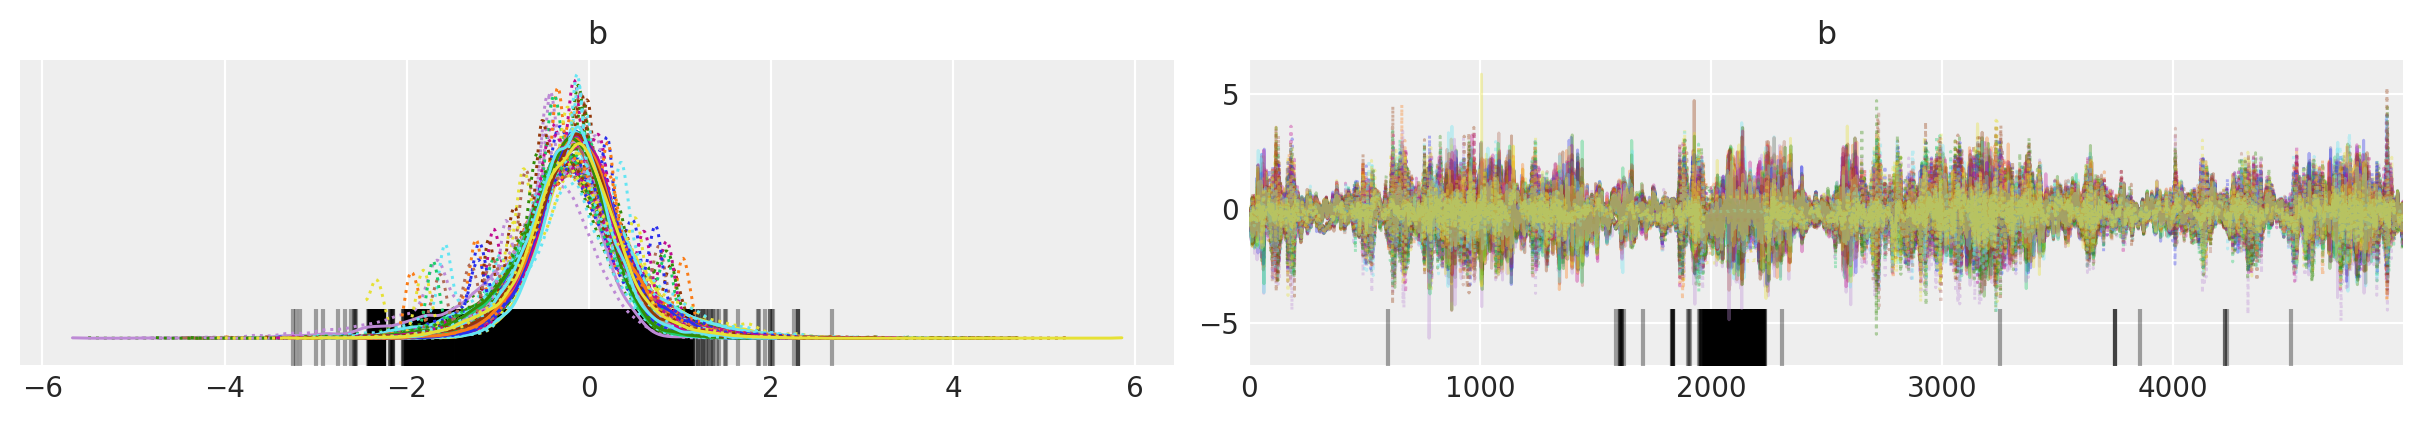

In [12]:
az.plot_trace(hierarchical_trace, var_names=["b"], coords={"participant": participant});


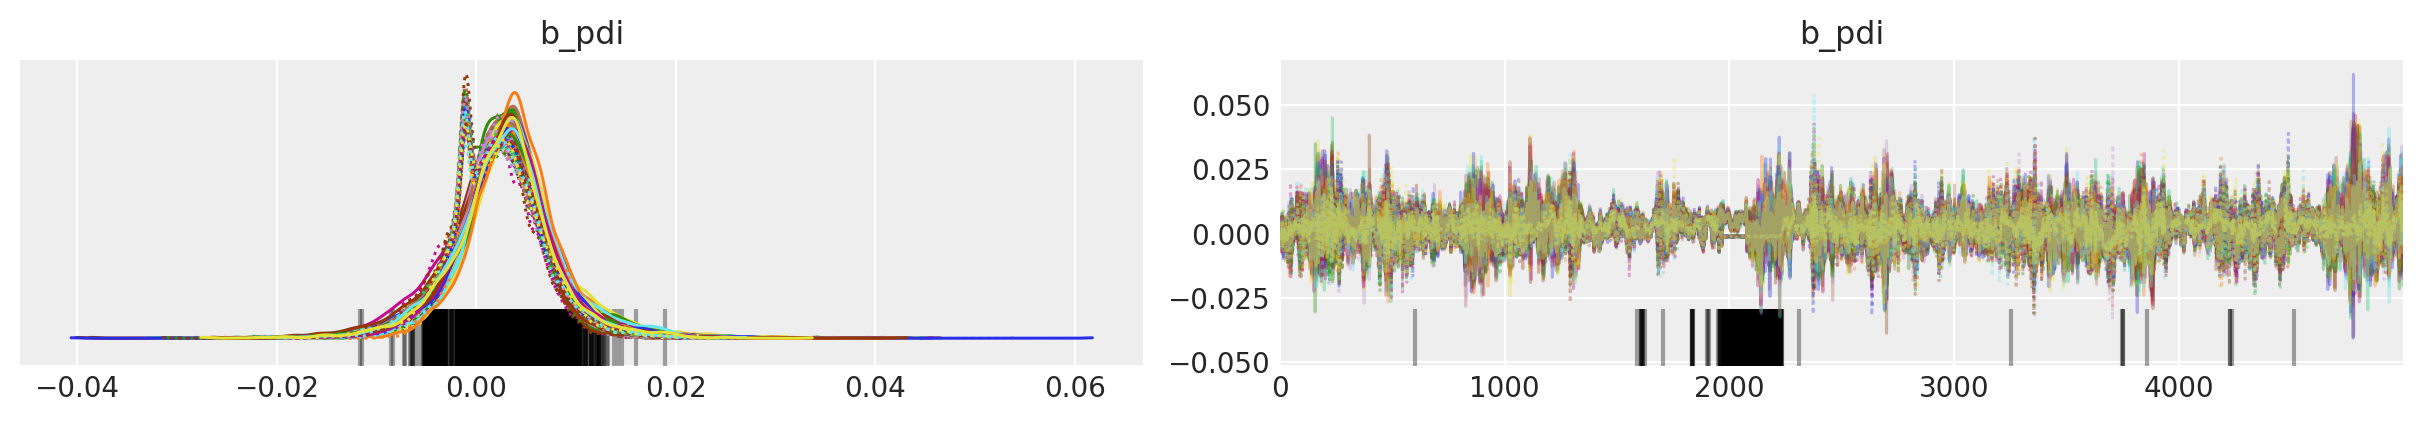

In [16]:
az.plot_trace(hierarchical_trace, var_names=["b_pdi"], coords={"participant": participant});


In [19]:
b_mu_reg_conf=stat_tms_reg_conf.loc['mu_b']['mean']
b_sigma_reg_conf=stat_tms_reg_conf.loc['mu_b']['sd']

b_mu_reg_conf_pdi=stat_tms_reg_conf.loc['mu_b_pdi']['mean']
b_sigma_reg_conf_pdi=stat_tms_reg_conf.loc['mu_b_pdi']['sd']

print ("Beta TMS =/0") 
b_tms_conf=NormalDist(mu=b_mu_reg_conf, sigma=b_sigma_reg_conf).overlap(NormalDist(mu=0, sigma=b_sigma_reg_conf))
print (b_tms_conf)

print ("Beta PDI =/0") 
b_tms_conf_pdi=NormalDist(mu=b_mu_reg_conf_pdi, sigma=b_sigma_reg_conf_pdi).overlap(NormalDist(mu=0, sigma=b_sigma_reg_conf_pdi))
print (b_tms_conf_pdi)

Beta TMS =/0
0.7506929750004536
Beta PDI =/0
0.6170750774519739


In [15]:
with hierarchical_model:
    ppc_reg = pm.sample_posterior_predictive(
        hierarchical_trace, var_names=["a", "b","confidence_like"]
    )

KeyError: 'confidence_like'

In [ ]:
az.plot_ppc(az.from_pymc3(posterior_predictive=ppc_reg, model=hierarchical_model))